In [1]:
import matplotlib.pyplot as plt
import json
import os
from collections import defaultdict

def plot(data, title):
    plt.figure(figsize=(20, 6))
    plt.margins(x=0)
    bars = plt.bar(data.keys(), data.values())
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', ha='center', va='bottom', rotation=90)

    plt.xticks(rotation=90)
    plt.title(title)
    plt.show()

In [2]:
def visualize_data(datapath):
    with open(datapath, 'r') as f:
        selected_repos = json.load(f)
    total = 0
    model_type = defaultdict(int)
    task = defaultdict(int)
    arch = defaultdict(int)
    for k, v in selected_repos.items():
        total += 1
        model_type[v['model_type']] += 1
        if isinstance(v['task'], list):
            for task_name in v['task']:#.split(","):
                task[task_name] += 1
        else:
            for task_name in v['task'].split(","):
                task[task_name] += 1
        arch[v['arch']] += 1
    model_type_to_repo_name_count = dict(sorted(model_type.items(), key=lambda x: (-x[1], x[0]), reverse=False))
    task_to_repo_name_count = dict(sorted(task.items(), key=lambda x: (-x[1], x[0]), reverse=False))
    arch_to_repo_name_count = dict(sorted(arch.items(), key=lambda x: (-x[1], x[0]), reverse=False))
    print(total)
    plot(model_type_to_repo_name_count, "Number of Repositories for each model_type")
    plot(task_to_repo_name_count, "Number of Repositories for each task")
    plot(arch_to_repo_name_count, "Number of Repositories for each architecture")
    return model_type_to_repo_name_count

4118


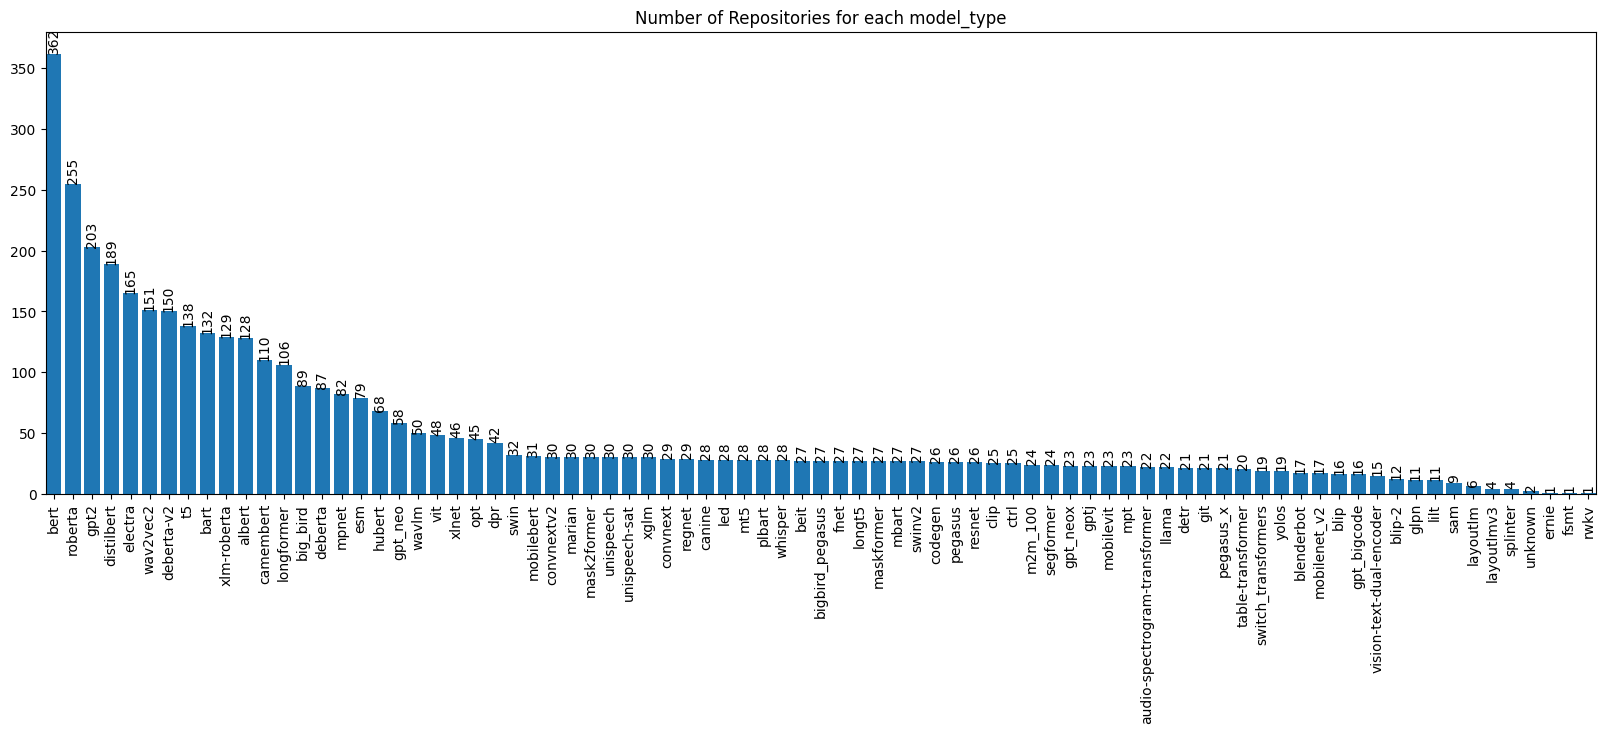

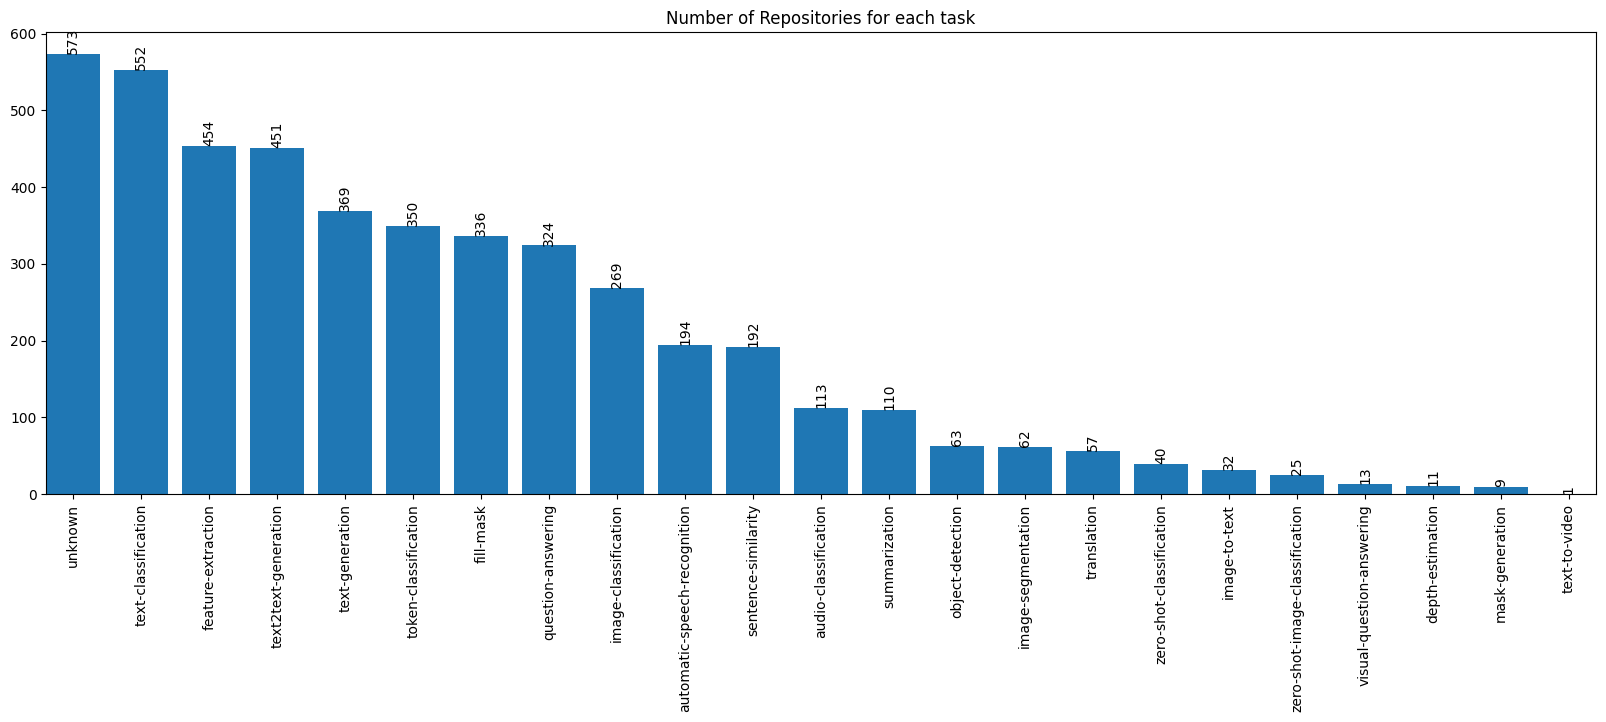

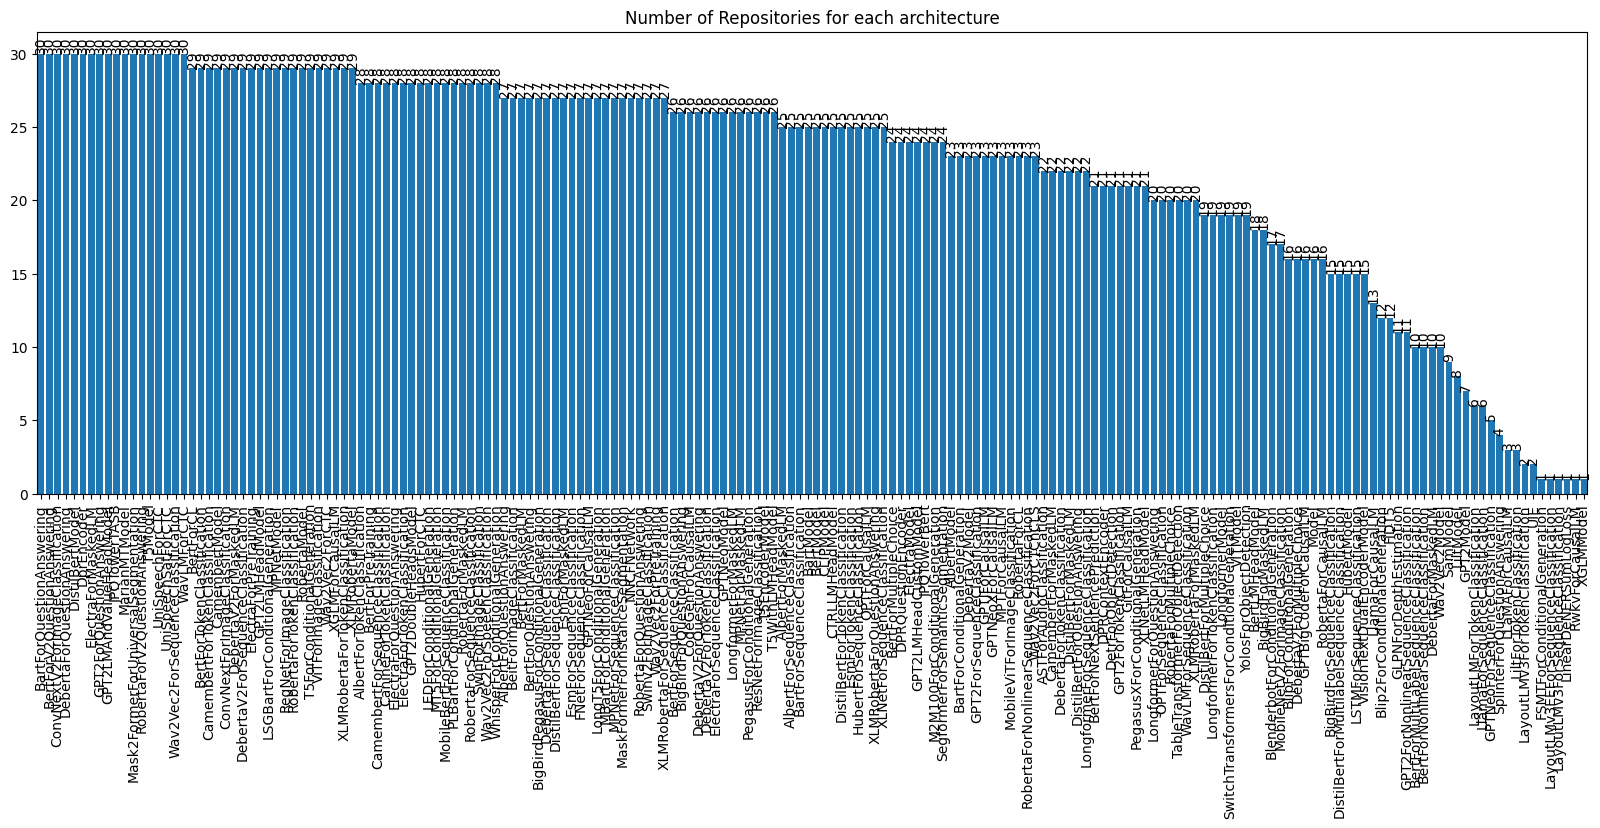

In [3]:
model_type_to_repo_name_count_1 = visualize_data("data/data.json")